# B-8802B — v2: pacote de PRODUÇÃO (`deploy_v2/Transpetro/B-8802B-2025`) — antes × depois

Este notebook lê **o bundle exatamente como a engenharia vai rodar** (módulo autocontido `simpred_inference.py`,
sem a lib interna) e compara **o modelo antigo (2022, pasta `B-8802B`) com o modelo atualizado (pasta `B-8802B-2025`)**
sobre o mesmo dado 2025–2026. As pastas coexistem de propósito, para manter o histórico da comparação.

**Pacote final:** VAE retreinado em 2025 (AutoML) · máscara de transiente de processo (90 min após degrau de pressão) ·
limiar **μ + 6,5·σ** do erro em operação normal · persistência **15 de 20** leituras.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, matplotlib.dates as mdates
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "deploy_v2").exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "deploy_v2/Transpetro"))
import simpred_inference as si                       # <- o módulo que a engenharia usa

NEW = ROOT / "deploy_v2/Transpetro/B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"
OLD = ROOT / "deploy_v2/Transpetro/B-8802B/modelos/model_2022-05-15_2022-07-21_VAE"
raw_new = si.carregar_dados(next((ROOT / "deploy_v2/Transpetro/B-8802B-2025/dados").rglob("*.csv")))   # 2025-26
raw_22  = si.carregar_dados(next((ROOT / "deploy_v2/Transpetro/B-8802B/dados").rglob("*.csv")))        # 2022
TRAIN_END, HELDOUT_END, FAILURE_2022 = pd.Timestamp("2026-01-01"), pd.Timestamp("2026-06-01"), pd.Timestamp("2022-07-06 10:00")
alarm_new = json.loads((NEW / "alarm.json").read_text()); alarm_old = json.loads((OLD / "alarm.json").read_text())
print("NOVO  :", [s["step"] for s in json.loads((NEW/"pipeline.json").read_text())])
print("        limiar", round(alarm_new["threshold"],4), "| persistência", alarm_new["debounce_min"], "de", alarm_new["debounce_window"], "| calibração", alarm_new["threshold_calibration"]["method"], "y =", alarm_new["threshold_calibration"]["y_alarm"])
print("ANTIGO:", [s["step"] for s in json.loads((OLD/"pipeline.json").read_text())])
print("        limiar", round(alarm_old["threshold"],4), "| persistência", alarm_old.get("debounce_min", alarm_old["debounce_consecutive"]), "de", alarm_old.get("debounce_window", alarm_old["debounce_consecutive"]))
def rodar(bundle, df): return si.prever(bundle, si.carregar_modelo(bundle), si.preprocessar(bundle, df))
def episodios(al): return 0 if len(al) == 0 else int((al.index.to_series().diff() > pd.Timedelta("12h")).sum() + 1)

NOVO  : ['remove_sensor_errors', 'filter_running', 'resample', 'ffill', 'remove_transients', 'remove_regime_transients', 'select_features', 'clip', 'normalize']
        limiar 0.3362 | persistência 15 de 20 | calibração sigma y = 6.5
ANTIGO: ['remove_sensor_errors', 'filter_running', 'resample', 'ffill', 'remove_transients', 'select_features', 'clip', 'normalize']
        limiar 0.4443 | persistência 6 de 6


## 1) Antes × depois — os dois bundles lendo o mesmo dado 2025–2026

,Modelo antigo (2022),Modelo atualizado (2025)
alarme geral 2025–26 (%),12.184,0.039
alarme em 2025 (%),8.826,0.014
alarme HELD-OUT jan–mai/26 (%),17.023,0.039
alarme jun–ago/26 (%),17.500,0.153
episódios (gap > 12 h),211.000,4.000
meses com zero alarme (de 20),0.000,16.000


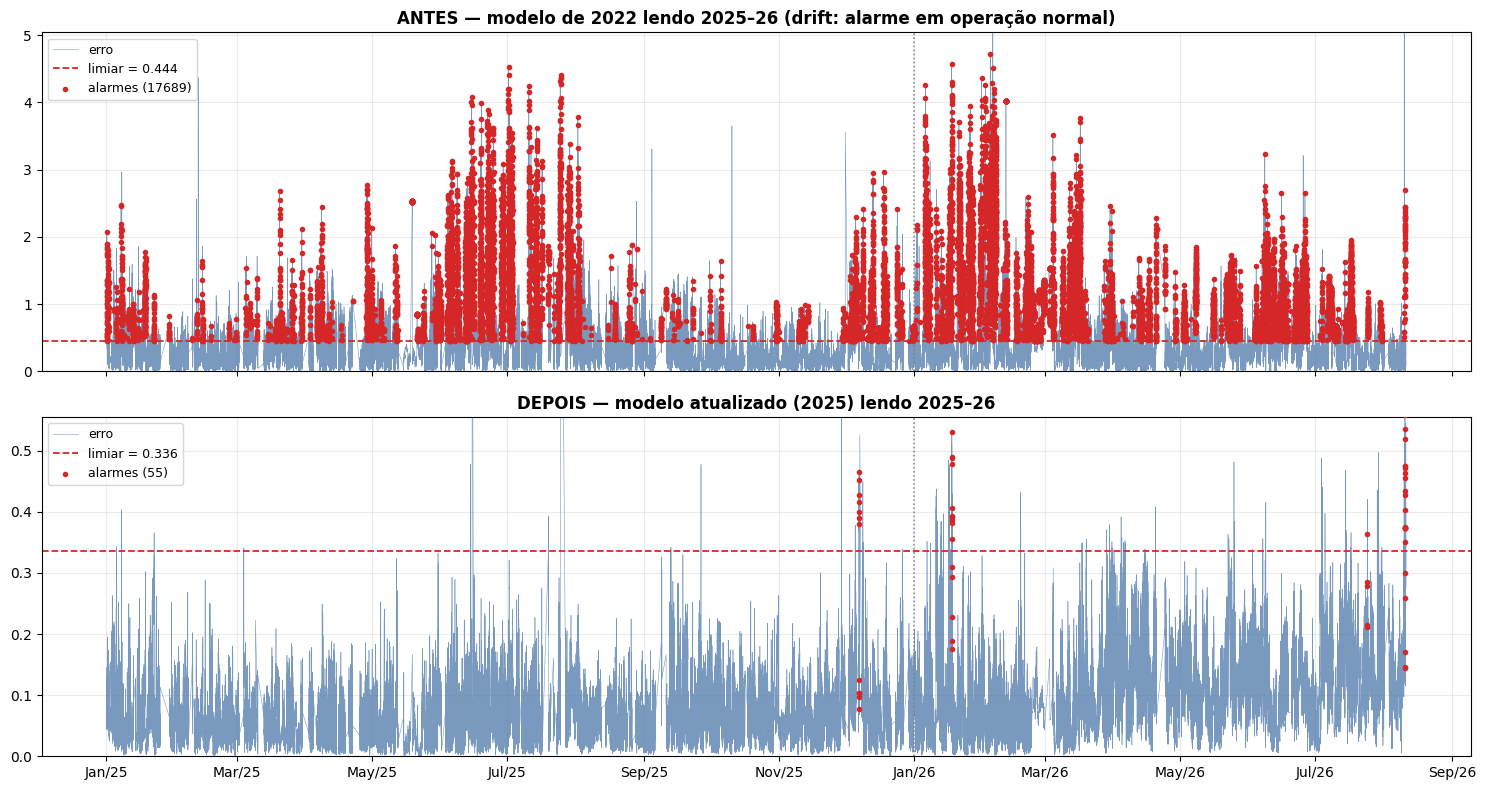

Episódios do modelo atualizado:
  06/12/2025 22:45 → 07/12 01:20  (12 leituras)
  17/01/2026 21:30 → 17/01 22:40  (15 leituras)
  24/07/2026 14:35 → 24/07 14:55  (5 leituras)
  10/08/2026 12:45 → 10/08 16:25  (23 leituras)


In [2]:
res_old = rodar(OLD, raw_new); res_new = rodar(NEW, raw_new)
def resumo(res):
    fl = res["is_anomaly"]; tr = res.index < TRAIN_END; ho = (res.index >= TRAIN_END) & (res.index < HELDOUT_END); post = res.index >= HELDOUT_END
    return {"alarme geral 2025–26 (%)": 100*fl.mean(), "alarme em 2025 (%)": 100*fl[tr].mean(),
            "alarme HELD-OUT jan–mai/26 (%)": 100*fl[ho].mean(), "alarme jun–ago/26 (%)": 100*fl[post].mean(),
            "episódios (gap > 12 h)": episodios(res[fl]), "meses com zero alarme (de 20)": int((fl.groupby(fl.index.to_period("M")).sum() == 0).sum())}
display(pd.DataFrame({"Modelo antigo (2022)": resumo(res_old), "Modelo atualizado (2025)": resumo(res_new)}).round(3))
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for ax, res, al, ttl in [(axes[0], res_old, alarm_old, "ANTES — modelo de 2022 lendo 2025–26 (drift: alarme em operação normal)"),
                         (axes[1], res_new, alarm_new, "DEPOIS — modelo atualizado (2025) lendo 2025–26")]:
    e = res["reconstruction_error"]; a = res[res["is_anomaly"]]
    ax.plot(e.index, e, lw=0.4, color="#4C78A8", alpha=0.75, label="erro"); ax.axhline(al["threshold"], color="#D62728", ls="--", lw=1.3, label=f"limiar = {al['threshold']:.3f}")
    ax.scatter(a.index, a["reconstruction_error"], s=9, color="#D62728", zorder=3, label=f"alarmes ({len(a)})"); ax.axvline(TRAIN_END, color="grey", ls=":", lw=1.1)
    ax.set_ylim(0, e.quantile(0.999)*1.4); ax.grid(alpha=0.25); ax.legend(loc="upper left", fontsize=9); ax.set_title(ttl, fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b/%y")); plt.tight_layout(); plt.show()
al = res_new[res_new["is_anomaly"]]; print("Episódios do modelo atualizado:")
for _, g in al.groupby((al.index.to_series().diff() > pd.Timedelta("12h")).cumsum()): print(f"  {g.index.min():%d/%m/%Y %H:%M} → {g.index.max():%d/%m %H:%M}  ({len(g)} leituras)")

> **06/12/25** (mancal da bomba LA aquecido) e **10/08/26** (pico de descarga a 73 bar, último dia dos dados) merecem verificação com a operação; os outros dois são curtos (≤ 1 h).

## 2) Sensibilidade: a falha real de 2022 vista pelos dois bundles

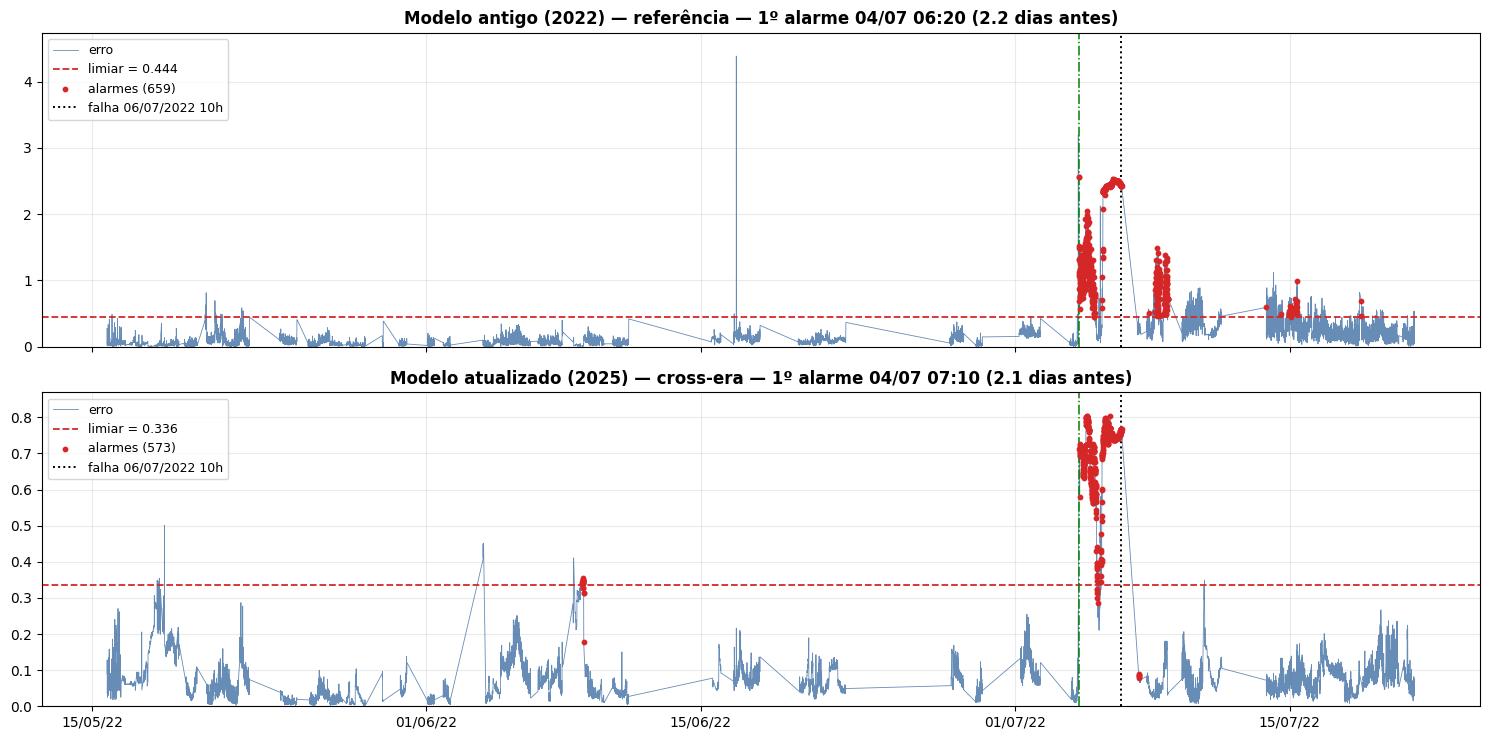

In [3]:
r22_new = rodar(NEW, raw_22); r22_old = rodar(OLD, raw_22)
fig, axes = plt.subplots(2, 1, figsize=(15, 7.5), sharex=True)
for ax, res, al, ttl in [(axes[0], r22_old, alarm_old, "Modelo antigo (2022) — referência"), (axes[1], r22_new, alarm_new, "Modelo atualizado (2025) — cross-era")]:
    e = res["reconstruction_error"]; a = res[res["is_anomaly"]]; ramp = a[(a.index >= "2022-06-29") & (a.index < FAILURE_2022)]; first = ramp.index.min()
    ax.plot(e.index, e, lw=0.6, color="#4C78A8", alpha=0.85, label="erro"); ax.axhline(al["threshold"], color="#D62728", ls="--", lw=1.3, label=f"limiar = {al['threshold']:.3f}")
    ax.scatter(a.index, a["reconstruction_error"], s=10, color="#D62728", zorder=3, label=f"alarmes ({len(a)})"); ax.axvline(FAILURE_2022, color="black", ls=":", lw=1.4, label="falha 06/07/2022 10h")
    ax.axvline(first, color="green", ls="-.", lw=1.1); ax.set_ylim(0, e.max()*1.08); ax.grid(alpha=0.25); ax.legend(loc="upper left", fontsize=9)
    ax.set_title(f"{ttl} — 1º alarme {first:%d/%m %H:%M} ({(FAILURE_2022-first).total_seconds()/86400:.1f} dias antes)", fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y")); plt.tight_layout(); plt.show()

## 3) Falha sintética (assinatura real de 2022 injetada em jun/2026) — bundle de produção

,1º alarme,antecedência
severidade,,
100% da falha de 2022,2026-06-11 01:50,22 h antes
50% da falha de 2022,2026-06-11 23:20,no evento (<1 h)
25% da falha de 2022,—,não detectada


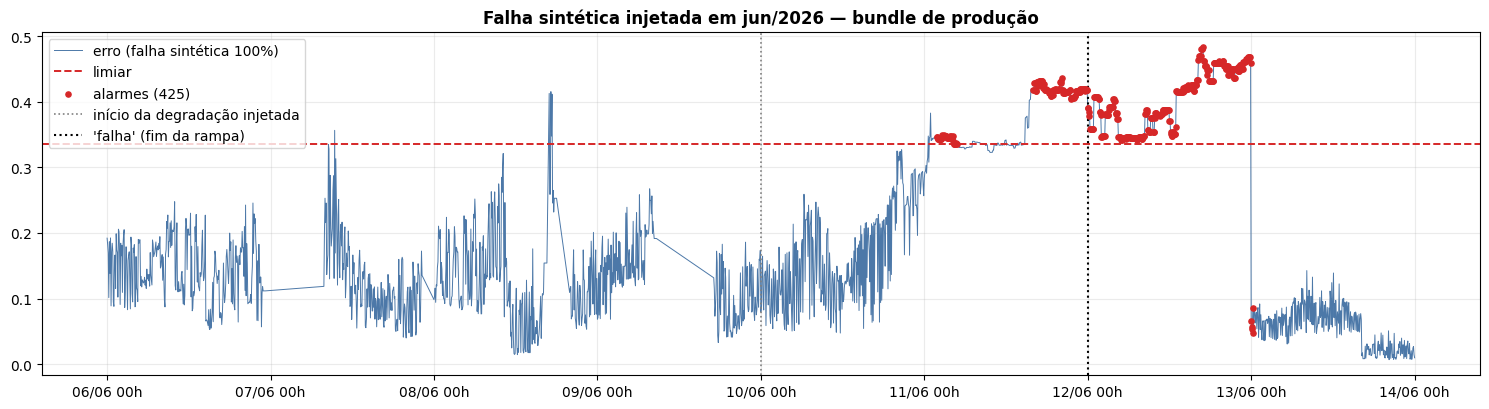

In [4]:
SIG = {"Pressão Sucção": -0.059, "Pressão Descarga": -1.535, "Vibração Bomba LA": 1.515, "Vibração Bomba LNA": 1.237, "Temperatura Bomba LA": 6.699}
T0 = pd.Timestamp("2026-06-10"); RAMP_H, HOLD_H = 48, 24; t_fail = T0 + pd.Timedelta(hours=RAMP_H)
rows, keep = [], None
for scale in (1.0, 0.5, 0.25):
    inj = raw_new.copy(); dt_h = np.asarray((inj.index - T0).total_seconds())/3600.0
    prof = np.clip(dt_h/RAMP_H, 0, 1); prof = np.where(dt_h < 0, 0, prof); prof = np.where(dt_h > RAMP_H+HOLD_H, 0, prof); running = (inj["Pressão Descarga"] > 35).values
    for c, dv in SIG.items(): inj[c] = inj[c].values + dv*scale*prof*running
    r = rodar(NEW, inj); win = (r.index >= T0) & (r.index <= t_fail + pd.Timedelta(hours=HOLD_H)); a = r[win & r["is_anomaly"]]
    fi = a.index.min() if len(a) else None; lead = (t_fail - fi) if fi is not None else None
    rows.append({"severidade": f"{int(100*scale)}% da falha de 2022", "1º alarme": str(fi)[:16] if fi is not None else "—",
                 "antecedência": (f"{int(lead.total_seconds()//3600)} h antes" if lead is not None and lead.total_seconds() >= 3600 else ("no evento (<1 h)" if fi is not None else "não detectada"))})
    if scale == 1.0: keep = r
display(pd.DataFrame(rows).set_index("severidade"))
z = keep[(keep.index >= T0 - pd.Timedelta(days=4)) & (keep.index <= t_fail + pd.Timedelta(days=2))]; az = z[z["is_anomaly"]]
fig, ax = plt.subplots(figsize=(15, 4.2)); ax.plot(z.index, z["reconstruction_error"], lw=0.7, color="#4C78A8", label="erro (falha sintética 100%)")
ax.axhline(alarm_new["threshold"], color="#D62728", ls="--", lw=1.4, label="limiar"); ax.scatter(az.index, az["reconstruction_error"], s=14, color="#D62728", zorder=3, label=f"alarmes ({len(az)})")
ax.axvline(T0, color="grey", ls=":", lw=1.2, label="início da degradação injetada"); ax.axvline(t_fail, color="black", ls=":", lw=1.5, label="'falha' (fim da rampa)")
ax.set_title("Falha sintética injetada em jun/2026 — bundle de produção", fontweight="bold"); ax.legend(loc="upper left"); ax.grid(alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh")); plt.tight_layout(); plt.show()

## Conclusão
- O bundle **B-8802B-2025** reproduz, **no código da engenharia**, os resultados da análise: FP ≈ 0 no held-out, falha de 2022
  detectada com ~2 dias, falha sintética detectada ~22 h antes. Está pronto para produção.
- A pasta **B-8802B** (2022) foi mantida como registro do "antes": 12% de alarme no dado novo = *concept drift* pós-reparo.
- **Roadmap:** verificar com a operação os episódios de 06/12/25 e 10/08/26; monitor de drift em produção (semanal); re-baseline após
  manutenção; retreino só com drift sustentado confirmado (janela de 6–12 meses).